# PREDICTING COMPANY BANKRUPTCY

PROJECT OVERVIEW
-
- Bankruptcy is when a business runs out of money and cannot pay its debts.
- It is rarely sudden and usually leaves early warning signs. This project analyzes those indicators to predict corporate failure before it happens, helping investors and lenders avoid major losses.
- The Problem: The company owes more money than it can make or borrow.The Process: A court gets involved to handle the remaining cash and property.The Outcome: The company either closes down or reorganizes to try to survive.


**AIMS OF THE PROJECT**
* Develop a predictive model: Build a machine learning classifier to accurately identify companies at risk of bankruptcy.
* Identify key financial predictors: Analyze company data to pinpoint the specific financial ratios that strongest indicate distress.
* Detect early warning signs: Discover the critical thresholds and patterns that signal financial decline before failure occurs.
* Enable proactive risk mitigation: Provide stakeholders with actionable insights to pull investments, deny risky credit, or restructure debt early

## BUSINESS UNDERSTANDING
*  Predicting this failure early allows different stakeholders to take action to protect their interests.
* Some of the stakeholders that might benefit from this project include:
    - Investors and Shareholders - They protect their capital maybe by buying out
    - Banks and Lenders - They reduce bad loan losses.
    - Suppliers and Vendors - They secure their supply chains and payments.
    - Company Executives and Board Members - They can save the business.

## DATA UNDERSTANDING
The data is sourced from [Kaggle](https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset)

The data contains the following variables:
- Variable Name	Description
- X1	Current assets - All the assets of a company that are expected to be sold or used as a result of standard
business operations over the next year
- X2	Cost of goods sold - The total amount a company paid as a cost directly related to the sale of products
- X3	Depreciation and amortization - Depreciation refers to the loss of value of a tangible fixed asset over
time (such as property, machinery, buildings, and plant). Amortization refers to the loss of value of
intangible assets over time.
- X4	EBITDA - Earnings before interest, taxes, depreciation, and amortization. It is a measure of a company's
overall financial performance, serving as an alternative to net income.
- X5	Inventory - The accounting of items and raw materials that a company either uses in production or sells.
- X6	Net Income - The overall profitability of a company after all expenses and costs have been deducted from
total revenue.
- X7	Total Receivables - The balance of money due to a firm for goods or services delivered or used but not
yet paid for by customers.
- X8	Market value - The price of an asset in a marketplace. In this dataset, it refers to the market
capitalization since companies are publicly traded in the stock market.
- X9	Net sales - The sum of a company's gross sales minus its returns, allowances, and discounts.
- X10	Total assets - All the assets, or items of value, a business owns.
- X11	Total Long-term debt - A company's loans and other liabilities that will not become due within one year
of the balance sheet date.
- X12	EBIT - Earnings before interest and taxes.
- X13	Gross Profit - The profit a business makes after subtracting all the costs that are related to
manufacturing and selling its products or services.
- X14	Total Current Liabilities - The sum of accounts payable, accrued liabilities, and taxes such as Bonds
payable at the end of the year, salaries, and commissions remaining.
- X15	Retained Earnings - The amount of profit a company has left over after paying all its direct costs,
indirect costs, income taxes, and its dividends to shareholders.
- X16	Total Revenue - The amount of income that a business has made from all sales before subtracting expenses.
It may include interest and dividends from investments.
- X17	Total Liabilities - The combined debts and obligations that the company owes to outside parties.
- X18	Total Operating Expenses - The expenses a business incurs through its normal business operations.

In [3]:
#IMPORT NECESSARY LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
#data loading and reading
data=pd.read_csv('american_bankruptcy.csv')
data.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [5]:
###looking at statistics
data.describe()

,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
count,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,7.868200e+04,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000
mean,2007.506317,880.362485,1594.529029,121.234256,376.759424,201.605717,129.382453,286.832743,3.414355e+03,2364.019706,2867.110620,722.483710,255.525035,769.490783,610.072255,532.467069,2364.019706,1773.563963,1987.260307
std,5.742768,3928.564794,8930.484664,652.376804,2012.023142,1060.766096,1265.532022,1335.978571,1.841410e+04,11950.068842,12917.944421,3242.170946,1494.643534,3774.703114,2938.387443,6369.159440,11950.068842,8053.684902,10419.629038
min,1999.000000,-7.760000,-366.645000,0.000000,-21913.000000,0.000000,-98696.000000,-0.006000,1.000000e-04,-1964.999000,0.001000,-0.023000,-25913.000000,-21536.000000,0.001000,-102362.000000,-1964.999000,0.001000,-317.197000
25%,2002.000000,18.924000,17.038250,1.192000,-0.811000,0.000000,-7.415750,3.281250,3.498000e+01,27.548500,37.363500,0.000000,-2.787000,8.521250,8.889250,-68.282750,27.548500,13.486000,32.872500
50%,2007.000000,100.449500,103.661000,7.929500,15.034500,7.023000,1.616000,22.820000,2.275118e+02,186.598500,213.203500,7.593500,6.518000,63.581500,43.333000,-1.131000,186.598500,81.988000,168.912000
75%,2012.000000,431.526750,634.548000,47.971750,139.655250,74.747250,40.144250,131.580500,1.244890e+03,1046.402500,1171.364750,248.760750,87.599000,344.074250,222.817000,146.070000,1046.402500,629.975000,875.522250
max,2018.000000,169662.000000,374623.000000,28430.000000,81730.000000,62567.000000,104821.000000,65812.000000,1.073391e+06,511729.000000,531864.000000,166250.000000,71230.000000,137106.000000,116866.000000,402089.000000,511729.000000,337980.000000,481580.000000


## DATA CLEANING AND INSPECTION

In [6]:
#looking for null values
data.isnull().sum()
#print('Data is null')

company_name    0
status_label    0
year            0
X1              0
X2              0
X3              0
X4              0
X5              0
X6              0
X7              0
X8              0
X9              0
X10             0
X11             0
X12             0
X13             0
X14             0
X15             0
X16             0
X17             0
X18             0
dtype: int64

In [7]:
#check for duplicates
data.duplicated().sum() #data has no duplicates

np.int64(0)

In [8]:
# If the row is "High", it becomes 1. Otherwise, it becomes 0.-converting status_label column to be numerical rather than categorical
data['status_label'] = np.where(data['status_label'] == 'alive', 1, 0)


In [9]:
#check for outliers
Q1 = data['status_label'].quantile(0.25)
Q3 = data['status_label'].quantile(0.75)
IQR = Q3 - Q1

# the boundaries
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

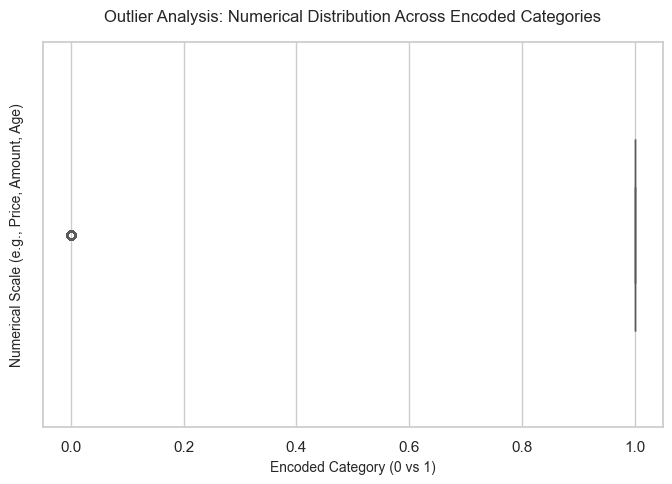

In [36]:
plt.figure(figsize=(8, 5))

# Generate the box plot splitting your numerical metric by the 0/1 classes
sns.boxplot(
    x='status_label',        # Your binary 0 and 1 column       # The numerical column you want to check for outliers
    data=bank, 
    palette="Set2",              # Distinct, professional color scheme
    width=0.5                    # Narrows the boxes for cleaner presentation
)

# Customize titles and labels for readability
plt.title("Outlier Analysis: Numerical Distribution Across Encoded Categories", fontsize=12, pad=15)
plt.xlabel("Encoded Category (0 vs 1)", fontsize=10)
plt.ylabel("Numerical Scale (e.g., Price, Amount, Age)", fontsize=10)

# Render the plot on screen
plt.show()

### EXPLORATORY DATA ANALYSIS

status_label
1    93.3657
0     6.6343
Name: proportion, dtype: float64


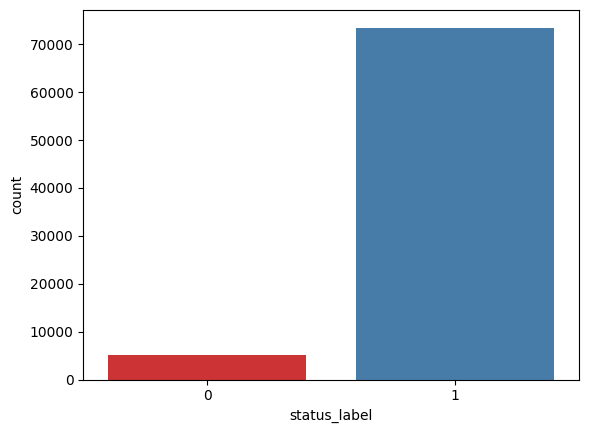

In [15]:
# TARGET VARIABLE
sns.countplot(data=data,x='status_label',palette='Set1')
#percentage of alive  and dead companies
#0-dead
#1-alive
status_label_percentage= data['status_label'].value_counts(normalize=True)*100
print(status_label_percentage)

### BIVARIATE ANALYSIS

In [40]:
### multivariate analysis


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,1,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,1,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,1,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,1,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


#### Multivariate Analysis

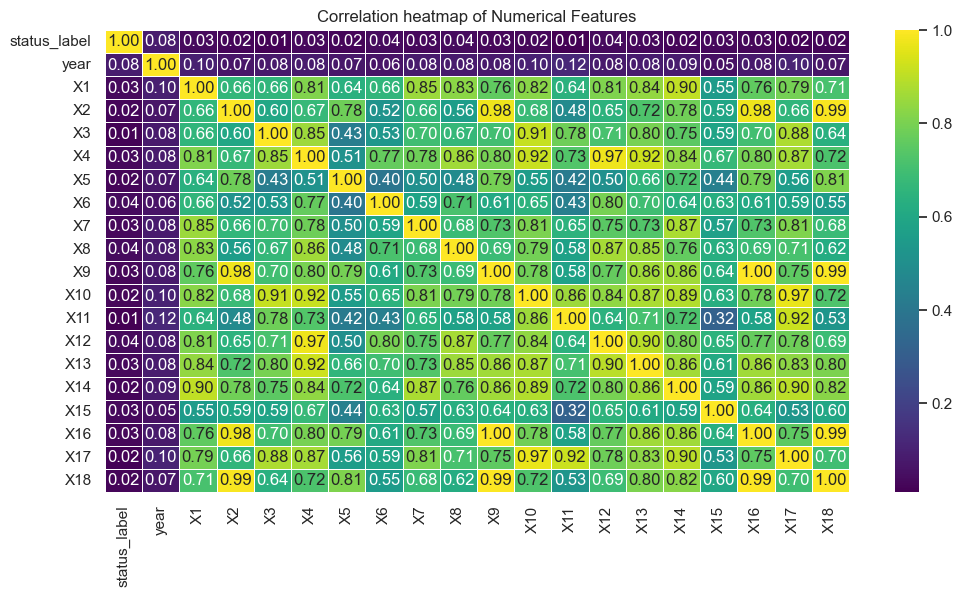

In [42]:
#correlation map
num_cols = ['status_label','year','X1','X2','X3','X4','X5','X6','X7','X8','X9','X10','X11','X12','X13','X14','X15','X16','X17','X18']

plt.figure(figsize=(12,6))
corr_matrix = bank[num_cols].corr()
sns.heatmap(corr_matrix,annot=True,cmap='viridis',fmt='.2f',linewidths=0.5)
plt.title('Correlation heatmap of Numerical Features')
plt.show()

**Findings**
-
* The 

## MODELING

In [1]:
#import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [16]:
#feature selection
X=data.drop(columns=['status_label'])#drop target column
y=data['status_label']

In [19]:
X

,company_name,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78677,C_8971,2014,233.211,43.338,14.094,45.615,3.376,25.261,22.846,756.4827,104.223,1099.101,184.666,31.521,60.885,28.197,28.095,104.223,225.887,58.608
78678,C_8971,2015,105.559,59.184,42.592,202.133,2.288,129.688,54.611,527.5750,291.153,1865.926,770.103,159.541,231.969,88.128,157.783,291.153,880.327,89.020
78679,C_8971,2016,63.971,69.074,65.057,79.051,2.581,-1.442,42.467,578.8868,169.858,1746.235,683.985,13.994,100.784,85.765,156.341,169.858,770.233,90.807
78680,C_8971,2017,135.207,66.527,65.330,69.171,2.013,-20.401,27.217,412.6241,161.884,1736.110,694.035,3.841,95.357,82.010,135.941,161.884,776.697,92.713


In [21]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#handling imbalance with smote
from imblearn.over_sampling import SMOTE
#instance
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X,y)
X_train,X_test,y_train,y_test=train_test_split(X_smote,y_smote,test_size=0.2,random_state=42)

ValueError: could not convert string to float: 'C_6'